In [1]:
import pandas as pd
import numpy as np
import openpyxl

import libs.append_path
from add_python_libraries import *
import pd_filter_fcns

#from ihlp_0v1 import Inductor_pdis, circuit_params, ind_pdis_obj, l_set, ihlp_filename
from cyntec import Inductor_pdis, lparams,create_ind_family_df, ind_pdis_obj, l_set, cyntec_filename
#from circuit_4state import circuit_params as circuit_params_4state
#from circuit_2state import circuit_params as circuit_params_2state

from current_buck_waveforms import Current_buck_waveforms
from current_carova_MR_waveforms import Current_carova_MR_waveforms

from current_buck_fft import Current_buck_FFT


import scipy as sp
import scipy.signal
import scipy.fftpack
import matplotlib.pyplot as plt

In [ ]:
# import scipy as sp
# import scipy.signal

# class Current_buck_waveforms:
#     def __init__(self, ind_obj):
#         self.lobj = ind_obj
#         self.level = self.lobj.ckt['ip']['lvl_config'] 
#         self.fs = self.lobj.ckt['ip']['fs']
#         self.ts13 = self.lobj.ckt['t_state13']; self.ts24 = self.lobj.ckt['t_state24']
#         self.duty = self.ts13/(self.ts13+self.ts24)        
#         #self.dfactor = {'2 level':1,'3 level':2}[self.level]
#         self.dfactor = {2:1,4:2}[self.lobj.ckt['state count']]
#         self.cycles=2; self.numpoints=1024; self.datapoints=np.linspace(0,1,self.numpoints) 
#         self.time_datapoints=np.linspace(0,self.cycles/(self.fs*self.dfactor),self.numpoints)
#         self.i_ind = self.create_ind_waveform()
#         self.i_hs = self.create_hs_waveform()
#         self.i_zin_ac  = self.create_i_zin_waveform()
        
#     def create_ind_waveform(self):
#         ipp = self.lobj.ipp; iout = self.lobj.idc      
#         if 'd_up_flag' in self.lobj.ckt:
#             waveform = sp.signal.sawtooth(2*np.pi*self.datapoints*self.cycles,self.duty)/2*ipp*(-1)**(not(self.lobj.ckt['d_up_flag']))+iout
#         else:
#             waveform = sp.signal.sawtooth(2*np.pi*self.datapoints*self.cycles,self.duty)/2*ipp+iout
#         return waveform

#     def create_hs_waveform(self):
#         if 'd_up_flag' in self.lobj.ckt:
#             time_scaler = self.datapoints[1]/self.time_datapoints[1]
#             tdelay = (self.lobj.ckt['t_state13']*(not(self.lobj.ckt['d_up_flag'])))*time_scaler
#         else:
#             tdelay=0
#         t_delayed = self.datapoints-tdelay
#         d_hs = self.lobj.ckt['t_Qhs']/(self.ts13+self.ts24)/self.dfactor
#         D_pulse = sp.signal.square(2*np.pi*t_delayed*self.cycles/self.dfactor,d_hs)/2+.5
#         return D_pulse*self.i_ind
        
#     def create_i_zin_waveform(self):
#         pin = self.lobj.ckt['ip']['pin']; vin = self.lobj.ckt['ip']['vin']
#         Iin_avg = np.mean(self.i_hs) #pin/vin
#         return self.i_hs-Iin_avg

#     def plot_waveforms(self,ax):
#         time_datapoints = self.time_datapoints
#         ax.plot(time_datapoints,self.i_ind,label='inductor')
#         ax.plot(time_datapoints,self.i_zin_ac,label='input cap total')
#         ax.legend(loc='lower left',bbox_to_anchor=(0.0,1.02));ax.grid(True,color='lime',linewidth=.2)


### Input Parameters

In [8]:
input_params = {'vin' : 20,
                'vout': 11.1,
                'pin' : 100, 
                'eff' : .96, 
                'fs'  :300e3,
                'ton_mult':1,
                'tambient':25,
                'lout':{'family'   :'hbed053t',
                        'value(uH)':1.5,
                        'config'   :'single'},
                'lvl_config':'3 level carova',  #2 level, 3 level, 3 level carova
               }
input_params['iout'] = input_params['pin']*input_params['eff']/input_params['vout']

### Time Based Waveforms

In [9]:
lobj = Inductor_pdis(input_params)
iobj = {True:Current_carova_MR_waveforms,
        False:Current_buck_waveforms}[lobj.ckt['state count']==6](lobj)
#iobj = Current_buck_waveforms(lobj) 
time_datapoints = iobj.time_datapoints
I_inductor = iobj.i_ind
I_hs = iobj.i_hs
I_ls = I_inductor-I_hs
I_zin_ac = iobj.i_zin_ac

([<matplotlib.lines.Line2D at 0x119ec5d10>],
 [<matplotlib.lines.Line2D at 0x119ec5e50>])

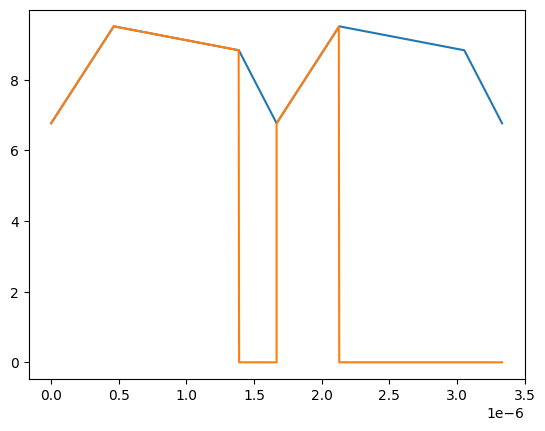

In [12]:
plt.plot(time_datapoints,I_inductor),plt.plot(time_datapoints,I_hs)

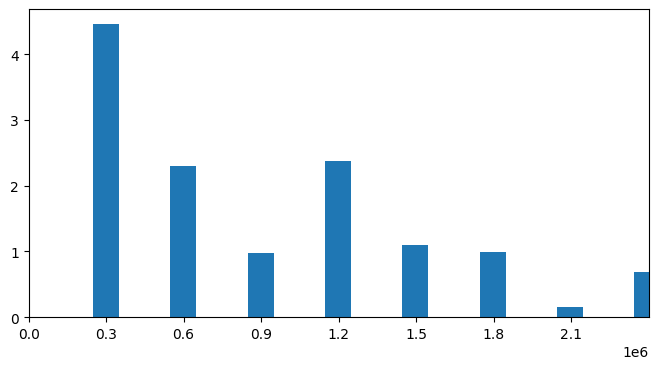

In [16]:
ifft = Current_buck_FFT(iobj)
ifft.plot_i_zin_fft()